In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# For text processing
from collections import Counter
import string

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('mbti_1.csv')

# Display the first 5 rows
display(df.head())

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [3]:
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
print("Dataset Information:")
df.info()
print("-" * 30)
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (8675, 2)
------------------------------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB
------------------------------
Missing Values:
type     0
posts    0
dtype: int64


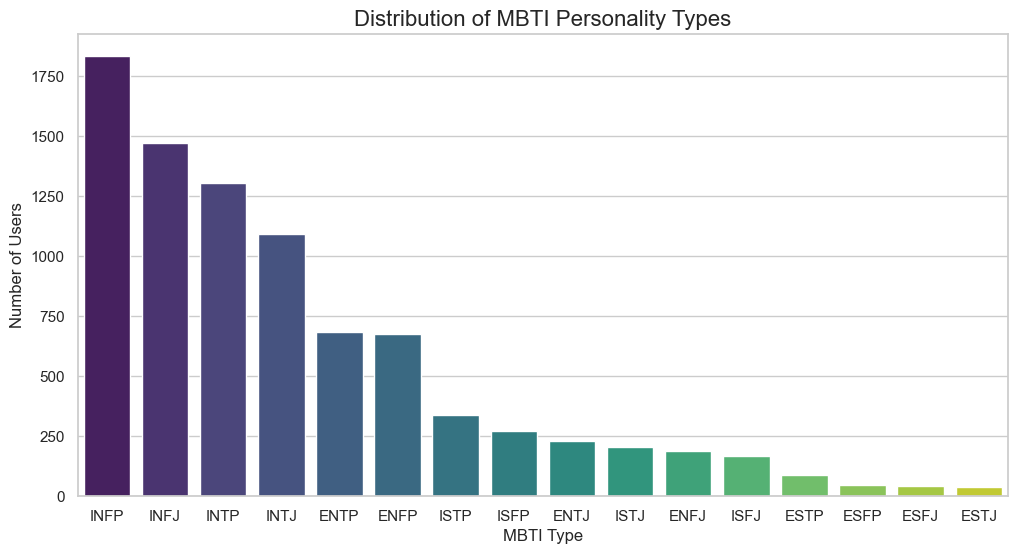

Exact counts per type:
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(12, 6))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')
plt.title('Distribution of MBTI Personality Types', fontsize=16)
plt.xlabel('MBTI Type', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()

# Print exact counts
print("Exact counts per type:")
print(type_counts)

In [5]:
# Count the number of posts per user (splitting by '|||')
df['num_posts'] = df['posts'].apply(lambda x: len(x.split('|||')))

# Calculate total length of all posts (in characters)
df['total_length'] = df['posts'].apply(len)

# Calculate total word count
df['word_count'] = df['posts'].apply(lambda x: len(x.split()))

# Calculate average words per post
df['avg_words_per_post'] = df['word_count'] / df['num_posts']

# Display the new features
display(df[['type', 'num_posts', 'total_length', 'word_count', 'avg_words_per_post']].head())

,type,num_posts,total_length,word_count,avg_words_per_post
0,INFJ,50,4652,556,11.12
1,ENTP,50,7053,1170,23.40
2,INTP,50,5265,836,16.72
3,INTJ,50,6271,1064,21.28
4,ENTJ,50,6111,967,19.34


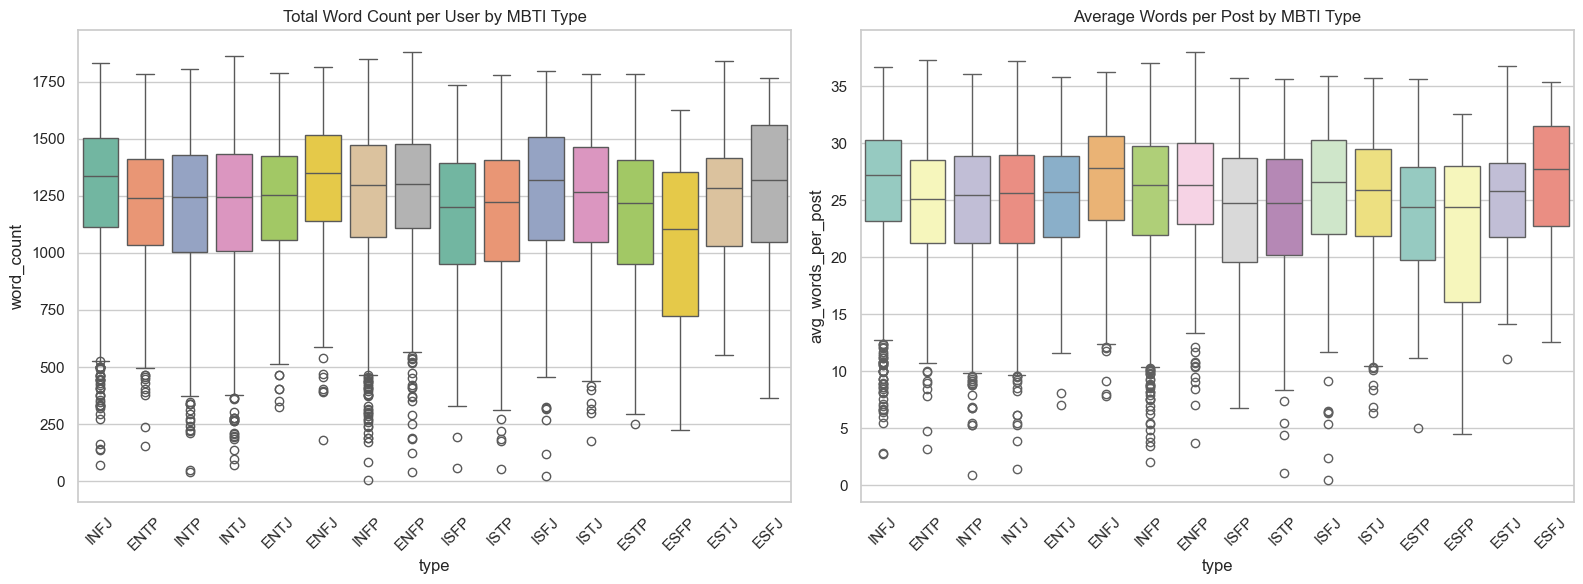

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot total word count distribution
sns.boxplot(x='type', y='word_count', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Total Word Count per User by MBTI Type')
axes[0].tick_params(axis='x', rotation=45)

# Plot average words per post distribution
sns.boxplot(x='type', y='avg_words_per_post', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Average Words per Post by MBTI Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://[^\s<>"]+|www\.[^\s<>"]+', ' ', text)
    # Remove separators '|||'
    text = text.replace('|||', ' ')
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to a sample or the whole dataset (this might take a minute)
print("Cleaning text...")
df['clean_posts'] = df['posts'].apply(clean_text)
print("Text cleaning complete. Here is a sample:")
print(df['clean_posts'].iloc[0][:200] + "...")

Cleaning text...
Text cleaning complete. Here is a sample:
and intj moments sportscenter not top ten plays pranks what has been the most lifechanging experience in your life on repeat for most of today may the perc experience immerse you the last thing my inf...


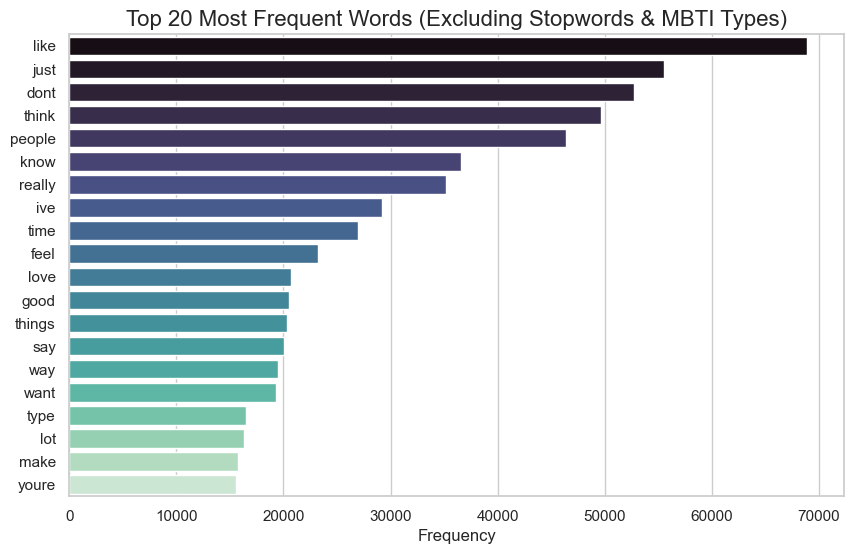

In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_most_common_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    # Filter out common stop words and MBTI type names which users often mention
    mbti_types = [x.lower() for x in df['type'].unique()]
    words = [word for word in all_words if word not in ENGLISH_STOP_WORDS and word not in mbti_types and len(word) > 2]
    return Counter(words).most_common(n)

# Get top 20 words for the whole dataset
top_words = get_most_common_words(df['clean_posts'], 20)

# Plot top words
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title('Top 20 Most Frequent Words (Excluding Stopwords & MBTI Types)', fontsize=16)
plt.xlabel('Frequency')
plt.show()